In [7]:
import schemdraw
import schemdraw.elements as elm
from schemdraw.segments import Segment, SegmentText  # <--- The Fix

In [88]:
class ArduinoUno(elm.Element):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        pin_separation = 0.4
        pin_font_size = 6.5

        height = 14*pin_separation + pin_separation/2

        width = 4
        
        # 1. Draw the main rectangle (The Body)
        self.segments.append(Segment([(0, 0), (width, 0), (width, height), (0, height), (0, 0)]))
        
        # 2. Add the Label in the middle
        self.anchors['center'] = (width/2, height/2)
        self.segments.append(SegmentText((width/2, height/2), 'Arduino Uno'))


        # Digital pins
        for i in range(13):
            name = f"D{i+1}"
            y = pin_separation*(i + 1)

            self.anchors[name] = (0, y)
            self.segments.append(Segment([(0, y), (-0.2, y)]))
            self.segments.append(SegmentText((0.2, y), name, align=('left', 'center'), fontsize=pin_font_size))

        # Analog pins
        for i in range(5):
            name = f"A{i+1}"
            y = pin_separation*(i + 1)

            self.anchors[name] = (width, y)
            self.segments.append(Segment([(width, y), (width + 0.2, y)]))
            self.segments.append(SegmentText((width - 0.2, y), name, align=('right', 'center'), fontsize=pin_font_size))
        


        # 4. Define Power Pins (Top Side)
        pins_top = ["GND", "5V", "3.3V"]
        for i,name in enumerate(pins_top):
            x = (i + 1)*width/(len(pins_top) + 1)
            self.anchors[name] = (x, height)
            self.segments.append(Segment([(x, height), (x, height + 0.2)]))
            self.segments.append(SegmentText((x, height - 0.2), name, align=('center', 'center'), fontsize=pin_font_size))


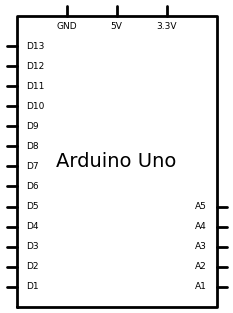

In [89]:
# --- THE ACTUAL DRAWING ---
with schemdraw.Drawing() as d:
    d.config(unit=1.2, fontsize=10)
    d += (UNO := ArduinoUno())
    
    # Let's test a logical connection! 
    #d += elm.Line().left().at(UNO.D12).length(1).label('To LCD RS', 'left')

In [ ]:
class MAX30102(elm.Element):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        pins_top = ["INT", "SDA", "SCL", "GND", "VIN"]

        pin_separation = 0.7
        pin_font_size = 6.5

        height = 2

        width = pin_separation*(len(pins_top) + 1)
        
    
        # 1. Draw the main rectangle (The Body)
        self.segments.append(Segment([(0, 0), (width, 0), (width, height), (0, height), (0, 0)]))
        

        # 2. Add the Label in the middle
        self.anchors['center'] = (width/2, height/2)
        self.segments.append(SegmentText((width/2, height/2), 'MAX30102'))

        # 3. Define Pin Locations (Left Side)
        pins_left = {
            'INT': 0.4, 'SDA': 0.8, 'SCL': 1.2, 'GND': 1.6, 
            'VIN': 2.0 
        }
        for i,name in enumerate(pins_top):
            x = (i + 1)*width/(len(pins_top) + 1)
            self.anchors[name] = (x, height)
            self.segments.append(Segment([(x, height), (x, height + 0.2)]))
            self.segments.append(SegmentText((x, height - 0.2), name, align=('center', 'center'), fontsize=pin_font_size))


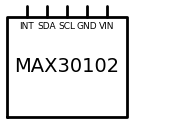

In [97]:
# --- THE ACTUAL DRAWING ---
with schemdraw.Drawing() as d:
    d.config(unit=1.2, fontsize=10)
    d += (sensor := MAX30102())
    
    # Let's test a logical connection! 
    #d += elm.Line().left().at(UNO.D12).length(1).label('To LCD RS', 'left')